In [ ]:
import numpy as np
import pandas as pd

# 加载 .npz 文件
data = np.load('../singleset/p3ht_singleset128.npz',allow_pickle=True)

# 'mol list', 'tempearture', 'total time', 'other info', 'r square array', 
# 'electron occupations array', 'phonon occupations array', 'k occupations array', 
# 'eph entropy', 'bond entropy', 'coherent length array', 'time series'
df = data['e_occupations']

df = pd.DataFrame(df)
print(df)
df.to_excel('p3ht_128_singleset.xlsx', index=False)

           0             1             2             3             4   \
0    1.000000  2.206063e-20  1.938605e-21  1.150238e-21  1.130178e-21   
1    0.889750  2.185350e-02  1.285741e-04  3.499993e-07  4.357479e-09   
2    0.616630  7.415090e-02  1.850378e-03  1.962527e-05  1.214332e-07   
3    0.316353  1.266575e-01  7.855902e-03  1.966522e-04  2.696555e-06   
4    0.118784  1.530654e-01  1.943043e-02  9.234732e-04  2.327864e-05   
..        ...           ...           ...           ...           ...   
197  0.074866  7.043419e-03  6.217457e-03  1.007945e-02  1.278557e-02   
198  0.072551  7.408705e-03  6.252635e-03  9.942603e-03  1.326328e-02   
199  0.070921  7.970757e-03  6.383061e-03  9.849277e-03  1.385207e-02   
200  0.069742  8.525591e-03  6.585245e-03  9.842548e-03  1.451021e-02   
201  0.068830  8.873207e-03  6.840695e-03  9.951082e-03  1.519125e-02   

               5             6             7             8             9   \
0    1.132030e-21  1.132816e-21  1.132991e-21 

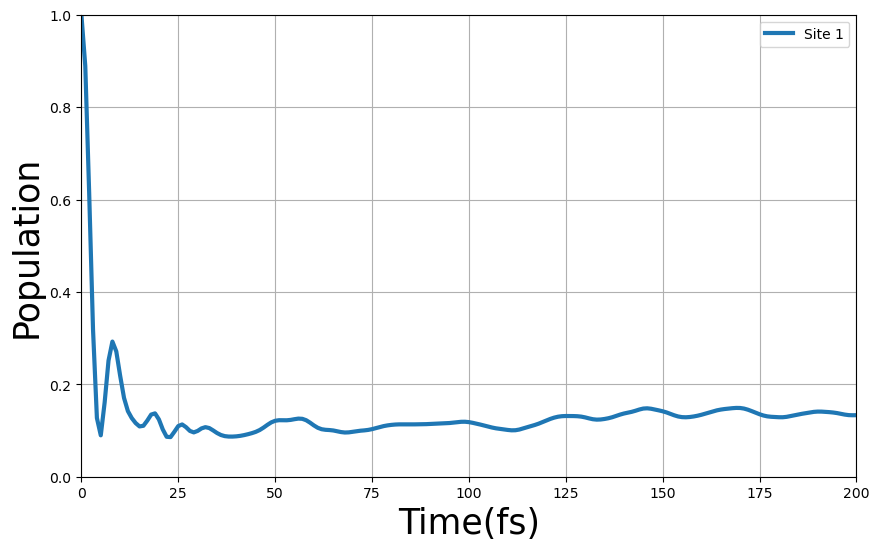

In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

excel_path = Path('p3ht_16_multiset.xlsx')

if not excel_path.exists():
    print(f'Skip: {excel_path} does not exist')
else:
    # 读取Excel文件
    df = pd.read_excel(excel_path)
    # df = pd.read_excel('../../fmo_benchmark.xlsx')

    # 提取数据
    x = np.arange(0,df.shape[0],1)
    x = x * 1 

    y_columns = df.iloc[:, 0:1]  # 第1-7列作为y坐标

    # 创建图表
    plt.figure(figsize=(10, 6))

    # 绘制七条线
    for i in range(0,y_columns.shape[1]):
        plt.plot(x, y_columns.iloc[:, i],label=f'Site {i+1}',linewidth=3)

    # 添加图表元素
    plt.xlabel('Time(fs)',size = 25)
    plt.ylabel('Population',size = 25)
    plt.xlim((0, 200))
    plt.ylim((0, 1))
    plt.title('')
    plt.legend()
    plt.grid(True)

    # 显示图表
    plt.show()

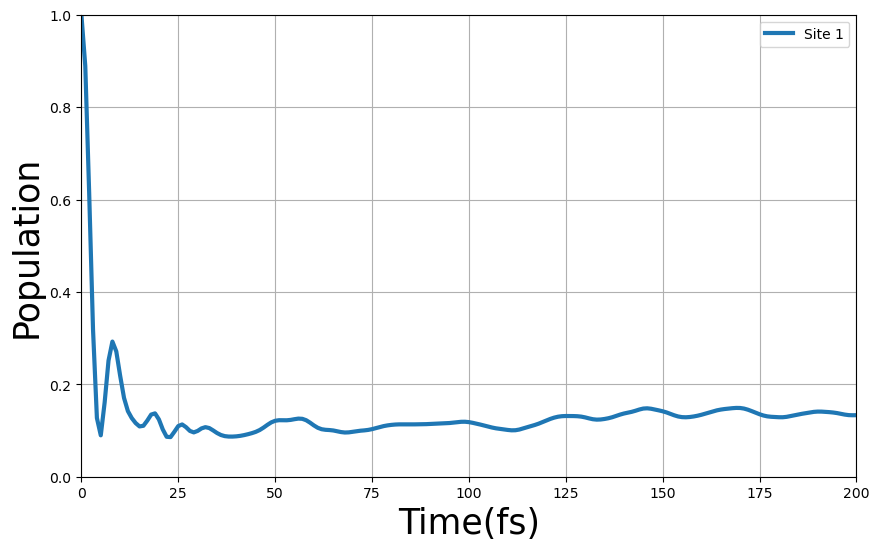

In [10]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

excel_path = Path('p3ht_16_multiset.xlsx')

if not excel_path.exists():
    print(f'Skip: {excel_path} does not exist')
else:
    # 读取Excel文件
    df = pd.read_excel(excel_path)
    # df = pd.read_excel('../../fmo_benchmark.xlsx')

    # 提取数据
    x = np.arange(0,df.shape[0],1)
    x = x * 1 

    y_columns = df.iloc[:, 0:1]  # 第1-7列作为y坐标

    # 创建图表
    plt.figure(figsize=(10, 6))

    # 绘制七条线
    for i in range(0,y_columns.shape[1]):
        plt.plot(x, y_columns.iloc[:, i],label=f'Site {i+1}',linewidth=3)

    # 添加图表元素
    plt.xlabel('Time(fs)',size = 25)
    plt.ylabel('Population',size = 25)
    plt.xlim((0, 200))
    plt.ylim((0, 1))
    plt.title('')
    plt.legend()
    plt.grid(True)

    # 显示图表
    plt.show()

Skip 128 multiset: missing p3ht_128_multiset.xlsx


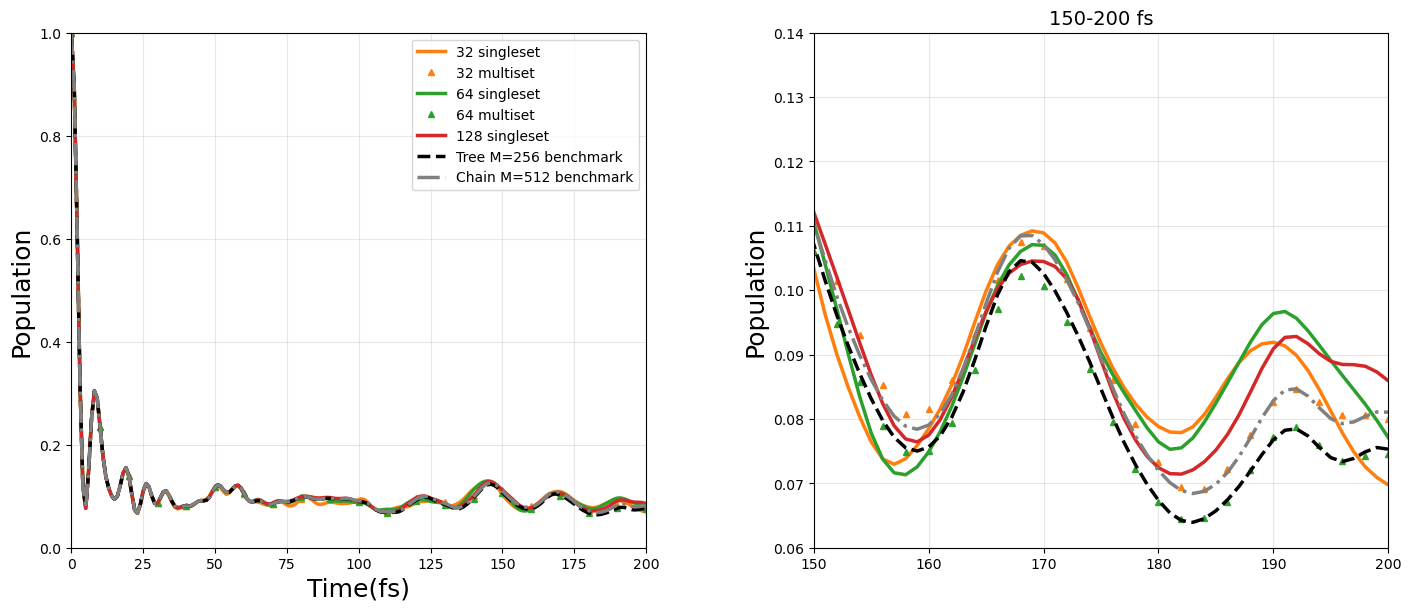

In [33]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datasets = [
    # ('16', 'p3ht_16_multiset.xlsx', 'p3ht_16_singleset.xlsx'),
    ('32', 'p3ht_32_multiset.xlsx', 'p3ht_32_singleset.xlsx'),
    ('64', 'p3ht_64_multiset.xlsx', 'p3ht_64_singleset.xlsx'),
    ('128', 'p3ht_128_multiset.xlsx', 'p3ht_128_singleset.xlsx'),
]

colors = {'16': 'tab:blue', '32': 'tab:orange', '64': 'tab:green', '128': 'tab:red'}
zoom_start, zoom_end = 150, 200
zoom_values = []
plotted = False

fig, (ax, ax_zoom) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    constrained_layout=True,
    gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.12},
)

for size, multiset_file, singleset_file in datasets:
    multiset_path = Path(multiset_file)
    singleset_path = Path(singleset_file)
    color = colors[size]

    if singleset_path.exists():
        df_single = pd.read_excel(singleset_path)
        x_single = np.arange(df_single.shape[0])
        y_single = df_single.iloc[:, 0:1].iloc[:, 0]
        zoom_values.extend(y_single[(x_single >= zoom_start) & (x_single <= zoom_end)].tolist())

        ax.plot(x_single, y_single, color=color, linewidth=2.5, label=f'{size} singleset')
        ax_zoom.plot(x_single, y_single, color=color, linewidth=2.5)
        plotted = True
    else:
        print(f'Skip {size} singleset: missing {singleset_path}')

    if multiset_path.exists():
        df_multi = pd.read_excel(multiset_path)
        x_multi = np.arange(df_multi.shape[0])
        y_multi = df_multi.iloc[:, 0:1].iloc[:, 0]
        zoom_values.extend(y_multi[(x_multi >= zoom_start) & (x_multi <= zoom_end)].tolist())

        ax.plot(
            x_multi,
            y_multi,
            color=color,
            linestyle='None',
            marker='^',
            markersize=5,
            markevery=10,
            label=f'{size} multiset',
        )
        ax_zoom.plot(
            x_multi,
            y_multi,
            color=color,
            linestyle='None',
            marker='^',
            markersize=5,
            markevery=2,
        )
        plotted = True
    else:
        print(f'Skip {size} multiset: missing {multiset_path}')


benchmark_path = Path("../../../multiset_ttn/P3HT:PCBM/2026Further_plot/figures/Tree5.npz")
if not benchmark_path.exists():
    benchmark_path = Path("multiset_ttn/P3HT:PCBM/2026Further_plot/figures/Tree5.npz")

if benchmark_path.exists():
    try:
        benchmark_npz = np.load(benchmark_path)
        benchmark_idx = benchmark_npz["M"].astype(str).tolist().index("256")
        y_benchmark = benchmark_npz["n"][benchmark_idx, 0]
        x_benchmark = np.arange(len(y_benchmark))
        zoom_values.extend(y_benchmark[(x_benchmark >= zoom_start) & (x_benchmark <= zoom_end)].tolist())

        ax.plot(
            x_benchmark,
            y_benchmark,
            color="black",
            linestyle="--",
            linewidth=2.5,
            label="Tree M=256 benchmark",
        )
        ax_zoom.plot(
            x_benchmark,
            y_benchmark,
            color="black",
            linestyle="--",
            linewidth=2.5,
        )
        plotted = True
    except (KeyError, ValueError, IndexError) as exc:
        print(f"Skip Tree M=256 benchmark: invalid {benchmark_path}: {exc}")
else:
    print(f"Skip Tree M=256 benchmark: missing {benchmark_path}")


chain_benchmark_path = Path("../../../multiset_ttn/P3HT:PCBM/2026Further_plot/figures/MPS.npz")
if not chain_benchmark_path.exists():
    chain_benchmark_path = Path("multiset_ttn/P3HT:PCBM/2026Further_plot/figures/MPS.npz")

if chain_benchmark_path.exists():
    try:
        chain_benchmark_npz = np.load(chain_benchmark_path)
        chain_benchmark_idx = chain_benchmark_npz["M"].astype(str).tolist().index("512")
        y_chain_benchmark = chain_benchmark_npz["n"][chain_benchmark_idx, 0]
        x_chain_benchmark = np.arange(len(y_chain_benchmark))
        zoom_values.extend(y_chain_benchmark[(x_chain_benchmark >= zoom_start) & (x_chain_benchmark <= zoom_end)].tolist())

        ax.plot(
            x_chain_benchmark,
            y_chain_benchmark,
            color="gray",
            linestyle="-.",
            linewidth=2.5,
            label="Chain M=512 benchmark",
        )
        ax_zoom.plot(
            x_chain_benchmark,
            y_chain_benchmark,
            color="gray",
            linestyle="-.",
            linewidth=2.5,
        )
        plotted = True
    except (KeyError, ValueError, IndexError) as exc:
        print(f"Skip Chain M=512 benchmark: invalid {chain_benchmark_path}: {exc}")
else:
    print(f"Skip Chain M=512 benchmark: missing {chain_benchmark_path}")

if not plotted:
    plt.close(fig)
    print('Skip plot: no dataset files found')
else:
    ax.set_xlabel('Time(fs)', size=18)
    ax.set_ylabel('Population', size=18)
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax_zoom.set_xlim(zoom_start, zoom_end)
    if zoom_values:
        zoom_min = min(zoom_values)
        zoom_max = max(zoom_values)
        zoom_margin = max((zoom_max - zoom_min) * 0.1, 1e-4)
        ax_zoom.set_ylim(zoom_min - zoom_margin, zoom_max + zoom_margin)
    ax_zoom.set_ylim(0.06, 0.14)
    ax_zoom.set_ylabel('Population', size=18)
    ax_zoom.set_title('150-200 fs', size=14)
    ax_zoom.grid(True, alpha=0.3)

    plt.show()


32 singleset: max ACE=4.0554e-03, mean ACE=2.0579e-03
32 multiset: max ACE=9.6390e-04, mean ACE=5.0615e-04
64 singleset: max ACE=2.9941e-03, mean ACE=1.0652e-03
64 multiset: max ACE=2.2510e-03, mean ACE=6.7550e-04
128 singleset: max ACE=1.5290e-03, mean ACE=4.8978e-04
Skip 128 multiset: missing p3ht_128_multiset.xlsx


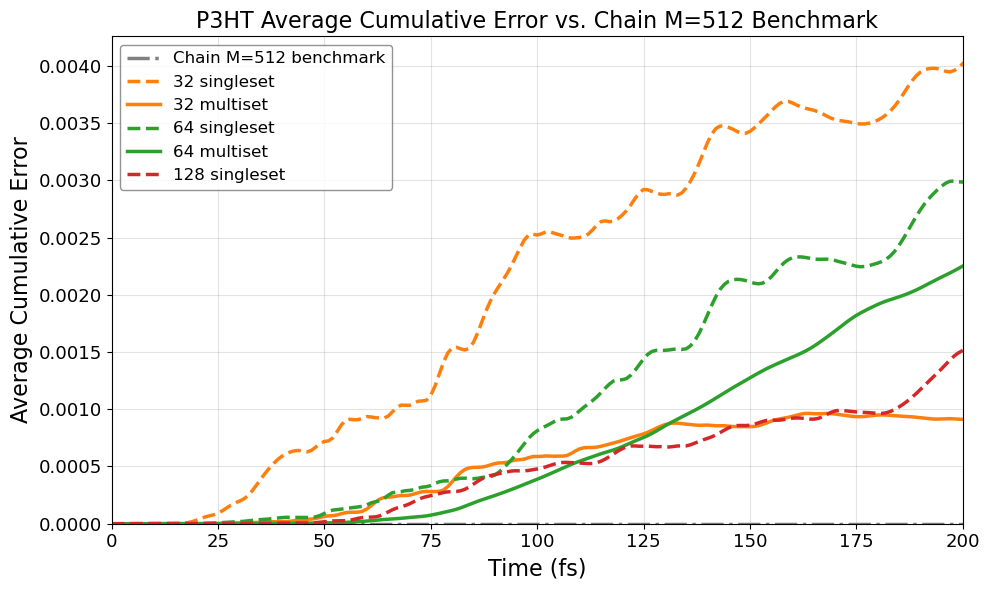

In [36]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

benchmark_path = Path("../../../multiset_ttn/P3HT:PCBM/2026Further_plot/figures/MPS.npz")
if not benchmark_path.exists():
    benchmark_path = Path("multiset_ttn/P3HT:PCBM/2026Further_plot/figures/MPS.npz")

data_files = [
    ("32 singleset", Path("p3ht_32_singleset.xlsx"), "tab:orange", "--"),
    ("32 multiset", Path("p3ht_32_multiset.xlsx"), "tab:orange", "-"),
    ("64 singleset", Path("p3ht_64_singleset.xlsx"), "tab:green", "--"),
    ("64 multiset", Path("p3ht_64_multiset.xlsx"), "tab:green", "-"),
    ("128 singleset", Path("p3ht_128_singleset.xlsx"), "tab:red", "--"),
    ("128 multiset", Path("p3ht_128_multiset.xlsx"), "tab:red", "-"),
]

dt_fs = 1.0


def cumulative_error(y, y_ref, x, x_ref):
    y_ref_interp = np.interp(x, x_ref, y_ref)
    abs_err = np.abs(y - y_ref_interp)
    err = np.zeros(len(x), dtype=float)
    if len(x) > 1:
        seg_integral = 0.5 * (abs_err[1:] + abs_err[:-1]) * np.diff(x)
        err[1:] = np.cumsum(seg_integral) / x[1:]
    return err


if not benchmark_path.exists():
    print(f"Skip cumulative error plot: missing {benchmark_path}")
else:
    benchmark_npz = np.load(benchmark_path)
    benchmark_idx = benchmark_npz["M"].astype(str).tolist().index("512")
    y_ref = benchmark_npz["n"][benchmark_idx, 0].astype(float)
    x_ref = np.arange(len(y_ref)) * dt_fs

    fig, ax = plt.subplots(figsize=(10, 6))
    plotted = False
    ax.plot(x_ref, np.zeros_like(x_ref), color="gray", linestyle="-.", linewidth=2.5, label="Chain M=512 benchmark")

    for label, path, color, linestyle in data_files:
        if not path.exists():
            print(f"Skip {label}: missing {path}")
            continue

        y = pd.read_excel(path).iloc[:, 0].to_numpy(dtype=float)
        x = np.arange(len(y)) * dt_fs
        err = cumulative_error(y, y_ref, x, x_ref)
        ax.plot(x, err, label=label, color=color, linestyle=linestyle, linewidth=2.5)
        plotted = True
        print(f"{label}: max ACE={err.max():.4e}, mean ACE={err.mean():.4e}")

    if not plotted:
        plt.close(fig)
        print("Skip cumulative error plot: no data files found")
    else:
        ax.set_xlabel("Time (fs)", fontsize=16)
        ax.set_ylabel("Average Cumulative Error", fontsize=16)
        ax.set_title("P3HT Average Cumulative Error vs. Chain M=512 Benchmark", fontsize=16)
        ax.set_xlim(0, 200)
        ax.set_ylim(bottom=0)
        ax.tick_params(labelsize=13)
        ax.legend(fontsize=12, framealpha=0.85, edgecolor="gray")
        ax.grid(True, alpha=0.35)
        plt.tight_layout()
        plt.savefig("P3HT_avg_cumulative_error_vs_chain_m512.png", dpi=150)
        plt.show()


32 singleset: max ACE=4.7398e-03, mean ACE=2.1284e-03
32 multiset: max ACE=2.3391e-03, mean ACE=7.8787e-04
64 singleset: max ACE=3.7327e-03, mean ACE=1.1277e-03
64 multiset: max ACE=6.8992e-04, mean ACE=2.7999e-04
128 singleset: max ACE=2.7069e-03, mean ACE=7.2954e-04
Skip 128 multiset: missing p3ht_128_multiset.xlsx


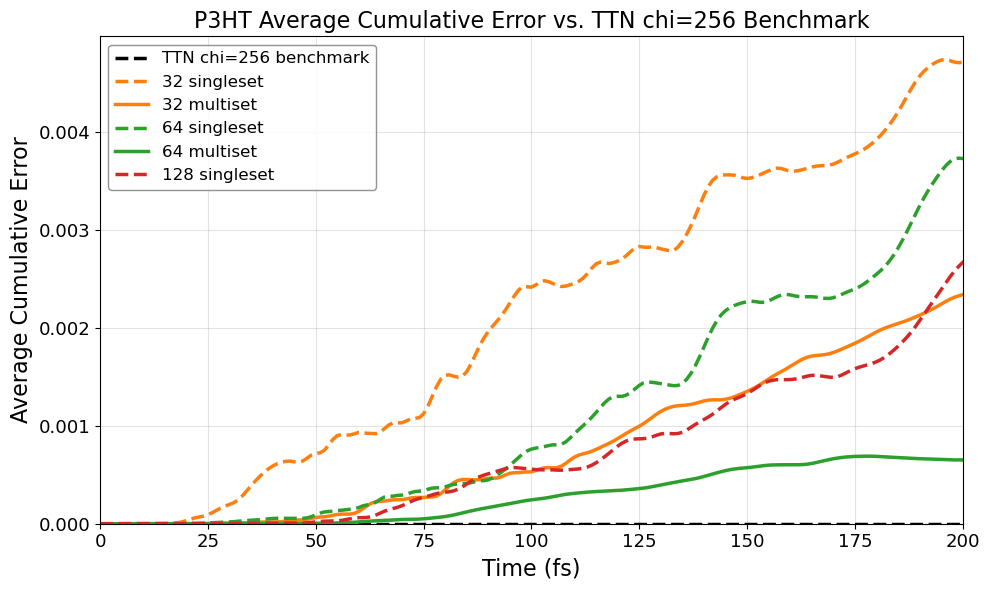

In [35]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

benchmark_path = Path("../../../multiset_ttn/P3HT:PCBM/2026Further_plot/figures/Tree5.npz")
if not benchmark_path.exists():
    benchmark_path = Path("multiset_ttn/P3HT:PCBM/2026Further_plot/figures/Tree5.npz")

data_files = [
    ("32 singleset", Path("p3ht_32_singleset.xlsx"), "tab:orange", "--"),
    ("32 multiset", Path("p3ht_32_multiset.xlsx"), "tab:orange", "-"),
    ("64 singleset", Path("p3ht_64_singleset.xlsx"), "tab:green", "--"),
    ("64 multiset", Path("p3ht_64_multiset.xlsx"), "tab:green", "-"),
    ("128 singleset", Path("p3ht_128_singleset.xlsx"), "tab:red", "--"),
    ("128 multiset", Path("p3ht_128_multiset.xlsx"), "tab:red", "-"),
]

dt_fs = 1.0


def cumulative_error(y, y_ref, x, x_ref):
    y_ref_interp = np.interp(x, x_ref, y_ref)
    abs_err = np.abs(y - y_ref_interp)
    err = np.zeros(len(x), dtype=float)
    if len(x) > 1:
        seg_integral = 0.5 * (abs_err[1:] + abs_err[:-1]) * np.diff(x)
        err[1:] = np.cumsum(seg_integral) / x[1:]
    return err


if not benchmark_path.exists():
    print(f"Skip cumulative error plot: missing {benchmark_path}")
else:
    benchmark_npz = np.load(benchmark_path)
    benchmark_idx = benchmark_npz["M"].astype(str).tolist().index("256")
    y_ref = benchmark_npz["n"][benchmark_idx, 0].astype(float)
    x_ref = np.arange(len(y_ref)) * dt_fs

    fig, ax = plt.subplots(figsize=(10, 6))
    plotted = False
    ax.plot(x_ref, np.zeros_like(x_ref), color="black", linestyle="--", linewidth=2.5, label="TTN chi=256 benchmark")

    for label, path, color, linestyle in data_files:
        if not path.exists():
            print(f"Skip {label}: missing {path}")
            continue

        y = pd.read_excel(path).iloc[:, 0].to_numpy(dtype=float)
        x = np.arange(len(y)) * dt_fs
        err = cumulative_error(y, y_ref, x, x_ref)
        ax.plot(x, err, label=label, color=color, linestyle=linestyle, linewidth=2.5)
        plotted = True
        print(f"{label}: max ACE={err.max():.4e}, mean ACE={err.mean():.4e}")

    if not plotted:
        plt.close(fig)
        print("Skip cumulative error plot: no data files found")
    else:
        ax.set_xlabel("Time (fs)", fontsize=16)
        ax.set_ylabel("Average Cumulative Error", fontsize=16)
        ax.set_title("P3HT Average Cumulative Error vs. TTN chi=256 Benchmark", fontsize=16)
        ax.set_xlim(0, 200)
        ax.set_ylim(bottom=0)
        ax.tick_params(labelsize=13)
        ax.legend(fontsize=12, framealpha=0.85, edgecolor="gray")
        ax.grid(True, alpha=0.35)
        plt.tight_layout()
        plt.savefig("P3HT_avg_cumulative_error_vs_ttn_chi256.png", dpi=150)
        plt.show()
